# **BUILDING A CNN MODEL FOR CROP DISEASE DETECTION**

**Objective**

* **Crop diseases are a major threat to agricultural productivity**, causing significant reduction in **crop yield and quality**.

* **Identifying plant diseases at an early stage is difficult**, especially for farmers who may not have access to expert knowledge or diagnostic tools.

* **Traditional (manual) disease detection methods are time-consuming and error-prone**, as they **rely on visual inspection by humans**.

* **Different diseases can have similar visual symptoms**, making accurate identification challenging without advanced techniques.

* **Variations in leaf images** such as **lighting conditions, background noise, and angles** further increase the difficulty of correct classification.

* Since the dataset contains **multiple crop types and disease categories,** the problem becomes a **multi-class classification task**, which is more complex than binary classification.

* Therefore, there is a need for an **automated, accurate, and scalable solution** that can detect and classify crop diseases from images using **deep learning.**                                                                                                           
-------------------
**Goals and Outcome**

* To build a **deep learning model that can accurately classify** crop diseases from leaf images.

* To perform **multi-class classification**, identifying different types of diseases across multiple crops.

* To **train the model using a real-world dataset** (Plant Disease Dataset from Kaggle) for better generalization.

* To achieve **high performance metrics** such as **accuracy, precision, recall, and F1-score.**

* To enable early and reliable **disease detection, helping in timely decision-making for crop management.**

* To **reduce dependency on manual inspection, saving time and effort for farmers** and agricultural experts.

* To develop a solution that can be extended to real-world applications, such as **mobile or web-based disease detection systems**

--------------------------
**Collect Data**

* The dataset used for this project is the **Plant Disease Dataset from Kaggle:**
https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

* This dataset contains **thousands of labeled images of plant leaves**, covering **multiple crops and disease categories**, making it suitable for a multi-class classification problem.
**bold text**
* Each image in the dataset is **properly labeled**, representing either a **specific plant disease or a healthy leaf**, which is essential for **supervised deep learning**.

* The dataset provides a **large volume of data**, which is important because deep learning models require sufficient data to learn meaningful patterns and achieve high accuracy.

* The images include **variations in real-world conditions**, such as **different lighting, backgrounds, angles, and leaf textures**, which helps improve the model’s generalization ability.

* The dataset is **well-structured**, typically organized into training and validation sets, making it easier to use for model training and evaluation.

* The **quality of the dataset is high**, with **clear images and accurate annotations**, ensuring reliable learning during model training.

* Overall, this dataset provides **both high quality and sufficient quantity of data**, which are essential for building a **robust and effective crop disease detection model.**

In [ ]:
#Installing Kaggle.
!pip install -q kaggle

In [ ]:
#Creating kaggle.json using token.
import json

kaggle_config = {
    "username": "swathy12345678",
    "key": "KGAT_7187fb8aa18b3f4220383d5b7bd6643a"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#Moving kaggle.json to correct folder.
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Testing Kaggle API.
!kaggle datasets list

ref                                                                      title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                           Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          32161        670                1  
laveshjadon/ai-impact-on-students                                        Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000           2385         57                1  
abdulmaliklodhra/social-media-addiction-and-mental-health-dataset        Social Media Addiction & Mental Health Dataset        13975225  2026-05-22 10:15:52.543000 

In [ ]:
#Downloading  Dataset.
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:38<00:00, 76.2MB/s]



In [ ]:
#Unzipping Dataset.
!unzip new-plant-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

In [ ]:
#Checking Dataset Structure.
import os
print(os.listdir())
print(os.listdir("new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"))

['.config', 'new-plant-diseases-dataset.zip', 'New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test', 'sample_data']
['train', 'valid']


**Pre-process the Data**

In [ ]:
#Import libaries

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Correct dataset path (nested folder fixed)
base_path = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")

# Verify paths
print("Train Exists:", os.path.exists(train_dir))
print("Validation Exists:", os.path.exists(valid_dir))

Train Exists: True
Validation Exists: True


In [ ]:
# Check number of classes
train_classes = os.listdir(train_dir)

print("Total Classes:", len(train_classes))
print("Sample Classes:", train_classes[:5])

Total Classes: 38
Sample Classes: ['Apple___Black_rot', 'Apple___healthy', 'Peach___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Late_blight']


In [ ]:
from PIL import Image
import os

def check_images(folder):
    corrupted = 0
    total = 0

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for img_file in os.listdir(class_path):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_path, img_file)
            total += 1

            try:
                img = Image.open(img_path)
                img.load()   #  better than verify()
            except:
                corrupted += 1

    print(f"Total Images Checked: {total}")
    print(f"Corrupted Images Found: {corrupted}")

# Run again
check_images(train_dir)

Total Images Checked: 70295
Corrupted Images Found: 0


In [ ]:
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
# Data augmentation to improve model performance

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Only normalization for validation data

valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load validation data
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
# Display class labels
print("Number of Classes:", len(train_generator.class_indices))
print("Class Labels:", train_generator.class_indices)

Number of Classes: 38
Class Labels: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29,

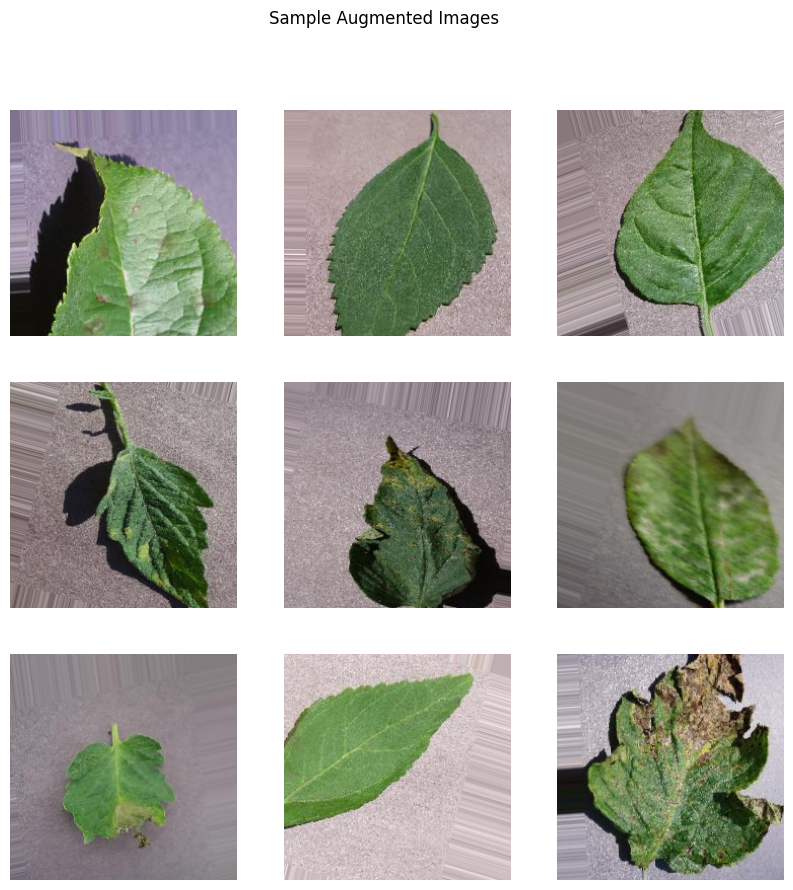

In [ ]:
# Visualize augmented images

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Sample Augmented Images")
plt.show()

# **Pre-process the Data - Summary**

* The dataset was first **validated to ensure correct folder structure and accessibility**, preventing errors during data loading.

* A **data cleaning step** was performed by checking for **corrupted or unreadable images**, ensuring that only valid images are used for training the model. This helps improve **data quality and model reliability**.

* All images were **resized to a fixed dimension (224 × 224 pixels)** to maintain **uniformity in input size**, which is required for deep learning models.

* Pixel values of images were **normalized to the range [0, 1]** by rescaling, which helps in **faster convergence and stable training** of the model.

* **Data augmentation techniques** were applied to the training dataset, including:

  * **Rotation** (to handle different orientations)
  * **Width and height shifting** (to simulate positional variations)
  * **Zooming** (to improve scale invariance)
  * **Horizontal flipping** (to increase data diversity)

* Data augmentation helps to **increase the effective size of the dataset** and reduces the risk of **overfitting**, thereby improving model generalization.

* The validation dataset was **only normalized (no augmentation applied)** to ensure that model performance is evaluated on **real, unaltered data**.

* The dataset was loaded using **ImageDataGenerator**, which allows efficient **batch-wise data loading and preprocessing**, reducing memory usage.

* The data was organized into **training and validation sets**, enabling proper **model training and performance evaluation**.

**Choose Framework and Architecture**
* For this project, the TensorFlow and Keras frameworks were selected because they are beginner-friendly, efficient, and widely used for deep learning applications.
* Since the project involves image classification, a Convolutional Neural Network (CNN) architecture is appropriate because CNNs are highly effective in extracting image features such as edges, textures, and patterns.
* To improve performance and reduce training time, Transfer Learning is used with the MobileNetV2 pre-trained model.
* MobileNetV2 is trained on the ImageNet dataset, enabling it to learn rich image features that can be transferred to the plant disease detection task.
* The pre-trained layers are used as a feature extractor, while custom classification layers are added for the 38 disease classes in the dataset.
Transfer learning helps achieve:
    * Higher accuracy
    * Faster training
    * Better generalization
    * Reduced computational cost

In [ ]:
#Import Required Libraries

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

In [ ]:
# Load MobileNetV2 pre-trained model

base_model = MobileNetV2(
    weights='imagenet',      # Use ImageNet pre-trained weights
    include_top=False,       # Remove original output layer
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers
base_model.trainable = False

print(" MobileNetV2 loaded successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MobileNetV2 loaded successfully


In [ ]:
#Build the CNN Model
# Build model using Transfer Learning

model = Sequential([

    # Pre-trained base model
    base_model,

    # Convert feature maps to vector
    GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(256, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer for multi-class classification
    Dense(38, activation='softmax')

])



In [ ]:
# Display model architecture

model.summary()

# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model Compiled Successfully")

 Model Compiled Successfully


**Train the Model**

* The dataset was divided into training and validation sets for proper model learning and evaluation.
* The training dataset is used to train the deep learning model, while the validation dataset is used to monitor performance on unseen data.
* The model was trained using the Adam optimizer, which provides efficient and adaptive learning during training.
* Since this is a multi-class classification problem, the categorical cross-entropy loss function was used.

Appropriate hyperparameters such as:

  * Batch Size
  * Learning Rate
  * Number of Epochs
  * Dropout

were selected to improve model performance and reduce overfitting.

* Transfer Learning with MobileNetV2 was used to reduce training time and improve accuracy.
* Google Colab cloud resources were utilized to leverage GPU acceleration, enabling faster model training.

In [ ]:
# Training parameters

EPOCHS = 5
BATCH_SIZE = 32

print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)

Epochs: 5
Batch Size: 32


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if validation loss does not improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Reduce learning rate automatically
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

print("Callbacks Created")

Callbacks Created


In [ ]:
# Train the model

history = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=EPOCHS,

    callbacks=[early_stopping, reduce_lr]

)

print("Model Training Completed")

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4675s 2s/step - accuracy: 0.7534 - loss: 0.8013 - val_accuracy: 0.8894 - val_loss: 0.3215 - learning_rate: 0.0010
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4645s 2s/step - accuracy: 0.8433 - loss: 0.4802 - val_accuracy: 0.9101 - val_loss: 0.2714 - learning_rate: 0.0010
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4666s 2s/step - accuracy: 0.8595 - loss: 0.4275 - val_accuracy: 0.9218 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4684s 2s/step - accuracy: 0.8665 - loss: 0.4050 - val_accuracy: 0.9244 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4647s 2s/step - accuracy: 0.8724 - loss: 0.3921 - val_accuracy: 0.9309 - val_loss: 0.2074 - learning_rate: 0.0010
Model Training Completed


In [ ]:
# Save trained model

model.save("crop_disease_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


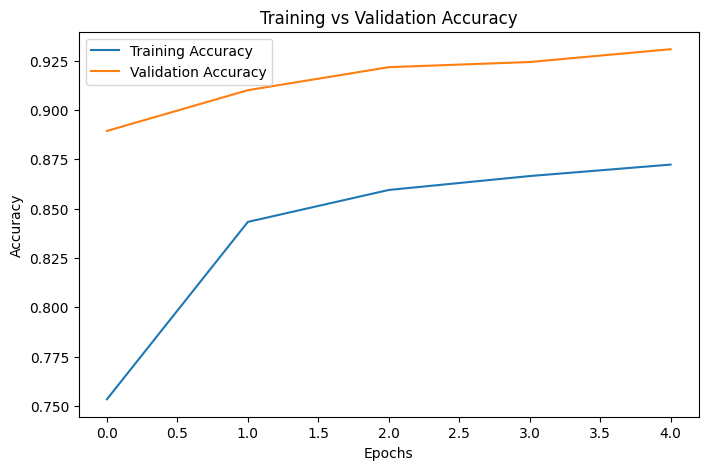

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

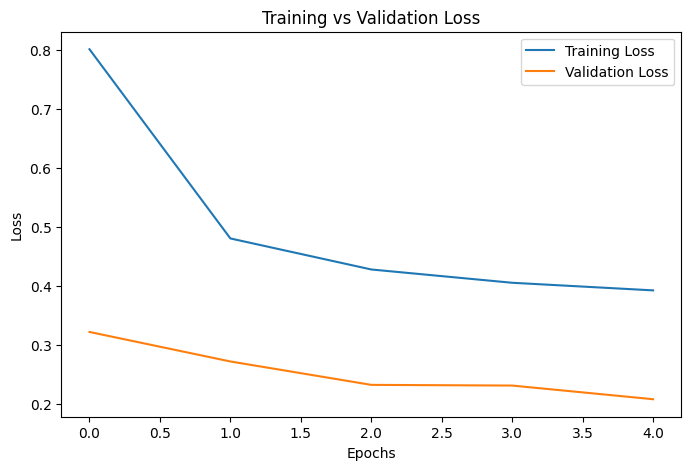

In [ ]:
# Plot loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Evaluate the Model**


* After training, the model performance was evaluated using multiple evaluation metrics.
* Accuracy was used to measure the percentage of correctly classified images.
* A confusion matrix was generated to analyze how well the model distinguishes between different disease classes.

Additional metrics such as:

*Precision
*Recall
*F1-score

were used to evaluate classification quality for each class.

* Learning curves for:

 *training accuracy
 *validation accuracy
*training loss
*validation loss

were visualized to monitor model learning behavior.

* Error analysis was performed to identify incorrectly classified images and potential areas for improvement.

In [ ]:

# Complete Model Evaluation


import os
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix



base_path = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

valid_dir = os.path.join(base_path, "valid")


valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


# Evaluate Model


test_loss, test_accuracy = model.evaluate(valid_generator)

print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")


# Predictions


predictions = model.predict(valid_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = valid_generator.classes


# Classification Report


class_labels = list(valid_generator.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print("\n✅ Classification Report:")
print(report)


# Confusion Matrix


cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print("\n✅ Confusion Matrix:")
print(cm)

Found 17572 images belonging to 38 classes.
550/550 ━━━━━━━━━━━━━━━━━━━━ 765s 1s/step - accuracy: 0.9309 - loss: 0.2074

✅ Test Accuracy: 93.09%
✅ Test Loss: 0.2074
550/550 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step

✅ Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.93      0.95       504
                                 Apple___Black_rot       0.96      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.97      0.97      0.97       440
                                   Apple___healthy       0.97      0.97      0.97       502
                               Blueberry___healthy       0.99      0.96      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       456
Corn_(maize)___Cercospora_leaf

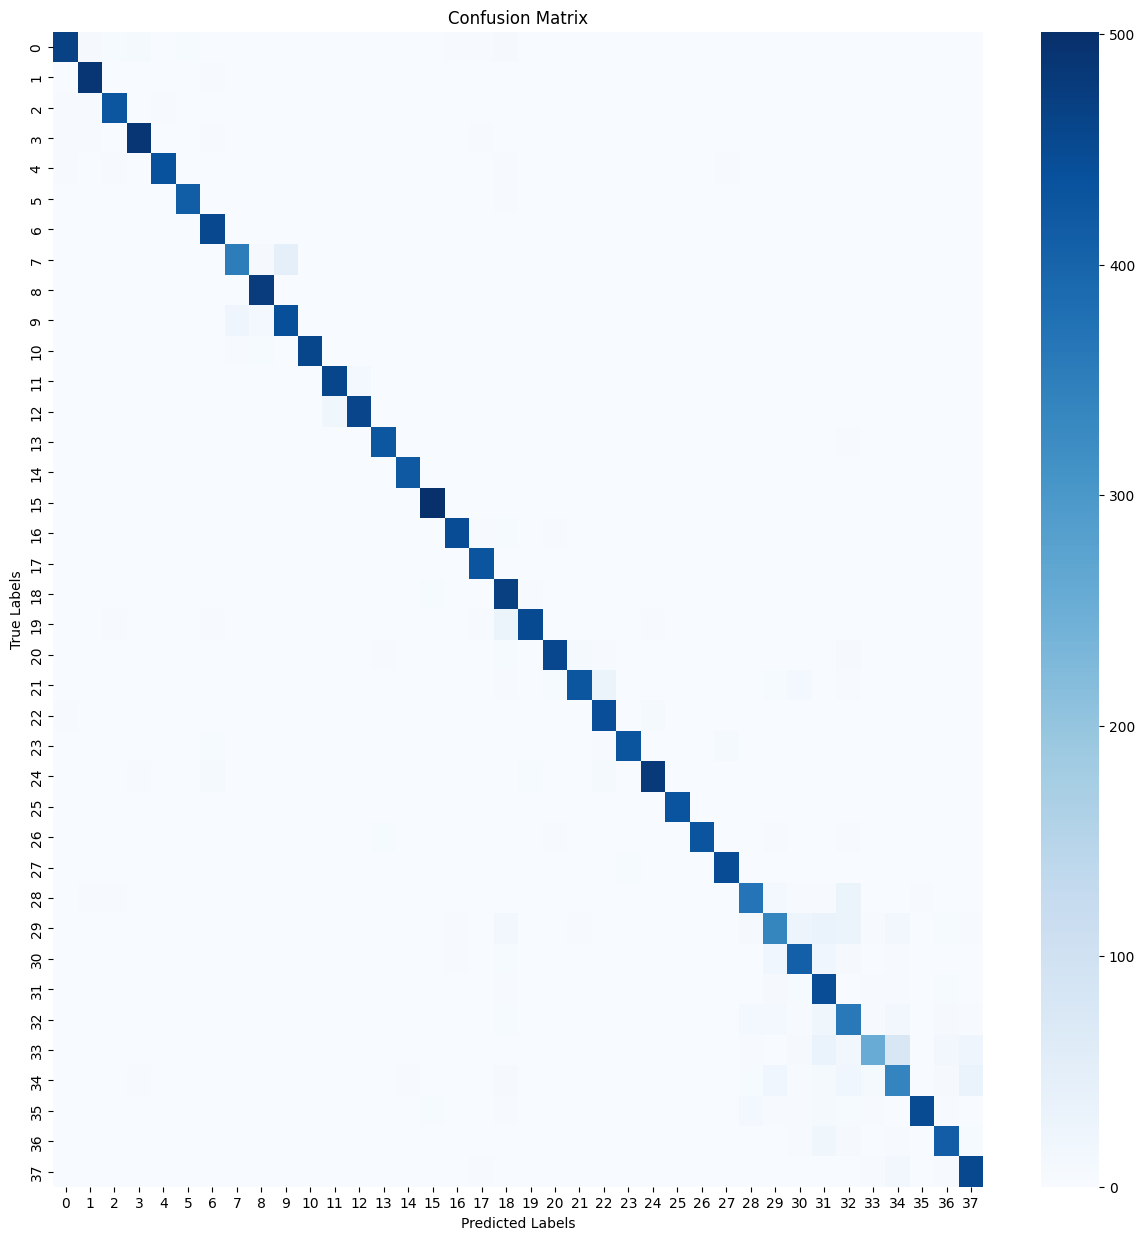

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(15,15))

sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

Saving Apple___Black_rot to Apple___Black_rot


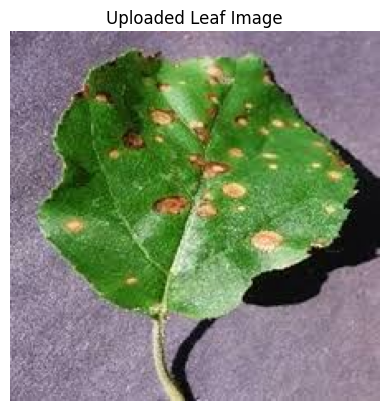

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
🌱 Predicted Disease:
Apple___Black_rot

 Confidence Score: 99.96%


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload external image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Display uploaded image
plt.imshow(img)
plt.title("Uploaded Leaf Image")
plt.axis('off')
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Normalize image
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict disease
prediction = model.predict(img_array)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Get class labels
class_names = list(train_generator.class_indices.keys())

# Predicted disease name
predicted_disease = class_names[predicted_index]

# Confidence score
confidence = np.max(prediction) * 100

# Display output
print("🌱 Predicted Disease:")
print(predicted_disease)

print(f"\n Confidence Score: {confidence:.2f}%")

In [ ]:
# Download model

from google.colab import files

files.download("crop_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>